# XGBOOST

## Importing necessary libraries

In [1]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier

## Read Data and keep only columns that we need

In [2]:
df = pd.read_csv("dns_traffic_data.csv")

# Drop unwanted columns if they exist
drop_cols = ['src_ip','dst_ip','udp_length','additional_count','rcode']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

df.head()

C:\Users\garam\AppData\Local\Temp\ipykernel_52752\1954400490.py:1: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dns_traffic_data.csv")


,timestamp,query_name,query_type,packet_length,is_response,answer_count,response_length,ttl,cname,txt_data,malicious_traffic
0,1693881903,361578368.www.ggy666.tk,16,83,False,0,NaN,NaN,NaN,NaN,1
1,1693881904,361578368.www.ggy666.tk,16,101,True,1,6.0,300.0,NaN,NoCMD,1
2,1693881907,99686406.www.ggy666.tk,16,82,False,0,NaN,NaN,NaN,NaN,1
3,1693881907,99686406.www.ggy666.tk,16,100,True,1,6.0,300.0,NaN,NoCMD,1
4,1693881910,767747460.www.ggy666.tk,16,83,False,0,NaN,NaN,NaN,NaN,1


## Encoding Binary Features and preparing data

In [3]:
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

bool_map = {
    "TRUE": 1, "FALSE": 0,
    "True": 1, "False": 0,
    "true": 1, "false": 0,
    True: 1, False: 0,
    1: 1, 0: 0,
    "1": 1, "0": 0
}

df["is_response"] = df["is_response"].map(bool_map)
df["malicious_traffic"] = df["malicious_traffic"].map(bool_map)

df["is_response"] = df["is_response"].fillna(0).astype(int)
df["malicious_traffic"] = df["malicious_traffic"].fillna(0).astype(int)

df["query_name"] = df["query_name"].fillna("").astype(str)
df["query_type"] = df["query_type"].fillna("").astype(str)
df["txt_data"] = df["txt_data"].fillna("").astype(str)

df["packet_length"] = pd.to_numeric(df["packet_length"], errors="coerce").fillna(0)
df["ttl"] = pd.to_numeric(df["ttl"], errors="coerce").fillna(0)
df["response_length"] = pd.to_numeric(df["response_length"], errors="coerce").fillna(0)
df["answer_count"] = pd.to_numeric(df["answer_count"], errors="coerce").fillna(0)

## Helper functions

In [4]:
def entropy(s):
    if not s:
        return 0
    counts = Counter(s)
    probs = [v/len(s) for v in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

def digit_ratio(s):
    if not s:
        return 0
    return sum(c.isdigit() for c in s) / len(s)

def special_ratio(s):
    if not s:
        return 0
    return sum(not c.isalnum() for c in s) / len(s)

def max_label_length(s):
    if not s:
        return 0
    return max(len(x) for x in s.split("."))

def extract_subdomain(s):
    parts = s.split(".")
    return ".".join(parts[:-2]) if len(parts) >= 3 else ""

## Derived Features calculations

In [5]:
df["entropy"] = df["query_name"].apply(entropy)
df["q_len"] = df["query_name"].apply(len)
df["digit_ratio"] = df["query_name"].apply(digit_ratio)
df["special_ratio"] = df["query_name"].apply(special_ratio)
df["max_label_len"] = df["query_name"].apply(max_label_length)
df["subdomain"] = df["query_name"].apply(extract_subdomain)

df["is_txt"] = (df["query_type"].str.upper() == "TXT").astype(int)
df["is_large_resp"] = (df["response_length"] > 300).astype(int)

# Window grouping (1 second)
df["window"] = df["timestamp"].astype(int)

## Aggregating querries into 1 second window's :

In [6]:
rows = []

for win, g in df.groupby("window"):
    g = g.sort_values("timestamp")
    
    query_count = (g["is_response"] == 0).sum()
    response_count = (g["is_response"] == 1).sum()
    total = len(g)

    # Label = 1 if ANY malicious exists
    label = int((g["malicious_traffic"] == 1).any())

    row = {
        "query_count": query_count,
        "response_count": response_count,

        "avg_packet_length": g["packet_length"].mean(),
        "std_packet_length": g["packet_length"].std(),

        "avg_entropy": g["entropy"].mean(),
        "max_entropy": g["entropy"].max(),

        "avg_qname_len": g["q_len"].mean(),
        "max_qname_len": g["q_len"].max(),

        "avg_digit_ratio": g["digit_ratio"].mean(),
        "avg_special_ratio": g["special_ratio"].mean(),

        "unique_subdomains": g["subdomain"].nunique(),
        "unique_qtypes": g["query_type"].nunique(),

        "txt_ratio": g["is_txt"].sum() / total if total else 0,
        "large_resp_ratio": g["is_large_resp"].sum() / total if total else 0,

        "avg_ttl": g["ttl"].mean(),
        "avg_max_label_len": g["max_label_len"].mean(),

        "answer_sum": g["answer_count"].sum(),
        "resp_len_avg": g["response_length"].mean(),

        "event_count": total,

        "malicious": label
    }

    rows.append(row)

window_df = pd.DataFrame(rows)

window_df.fillna(0, inplace=True)

window_df.head()

,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count,malicious
0,2,1,99.000000,12.124356,3.771822,4.577697,32.000000,46,0.145217,0.101739,2,1,0.0,0.00,0.0,18.000000,1.0,3.000000,3,1
1,3,3,135.666667,26.530486,4.007719,4.577697,43.333333,64,0.108603,0.165746,4,1,0.0,0.00,0.0,29.333333,3.0,20.833333,6,1
2,4,4,153.250000,37.833281,3.696685,5.629004,57.000000,70,0.130297,0.363273,5,1,0.0,0.00,0.0,43.000000,4.0,24.750000,8,1
3,4,4,478.500000,519.162237,2.715733,3.410694,158.625000,253,0.082780,0.357642,5,1,0.0,0.25,0.0,39.250000,4.0,241.375000,8,1
4,1,0,324.000000,0.000000,3.181255,3.181255,253.000000,253,0.011858,0.256917,1,1,0.0,0.00,0.0,62.000000,0.0,0.000000,1,1


In [7]:
print(window_df["malicious"].value_counts())
print(window_df["malicious"].value_counts(normalize=True))

malicious
1    63267
0    17057
Name: count, dtype: int64
malicious
1    0.787648
0    0.212352
Name: proportion, dtype: float64


## Data Splitting

In [8]:
from sklearn.model_selection import train_test_split

X = window_df.drop(columns=["malicious"])
y = window_df["malicious"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_test1 = X_test.copy()

print("Train distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Train distribution:
malicious
1    50613
0    13646
Name: count, dtype: int64

Test distribution:
malicious
1    12654
0     3411
Name: count, dtype: int64


In [9]:
neg_count = (y_train == 0).sum()   # benign
pos_count = (y_train == 1).sum()   # malicious

scale_pos_weight = neg_count / pos_count

print("Benign count (0):", neg_count)
print("Malicious count (1):", pos_count)
print("scale_pos_weight:", scale_pos_weight)

Benign count (0): 13646
Malicious count (1): 50613
scale_pos_weight: 0.269614525912315


## Training Weighted XGBOOST model

In [10]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Evaluation

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Confusion matrix

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Confusion Matrix:
[[ 3410     1]
 [    4 12650]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9997    0.9993      3411
           1     0.9999    0.9997    0.9998     12654

    accuracy                         0.9997     16065
   macro avg     0.9994    0.9997    0.9995     16065
weighted avg     0.9997    0.9997    0.9997     16065



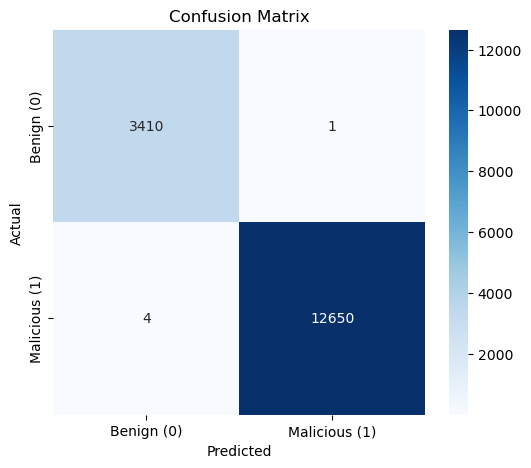

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Testing our model agains wildcard dns traffic ( traffic that looks very malicious but it is not malicious )

### Importing dataset

In [14]:
import pandas as pd
import numpy as np

wild_df = pd.read_csv("wildcard_dns.csv")

# Drop same columns as training
drop_cols = ['src_ip','dst_ip','udp_length','additional_count','rcode']
wild_df = wild_df.drop(columns=[c for c in drop_cols if c in wild_df.columns], errors='ignore')

wild_df.head()

,timestamp,query_name,query_type,packet_length,is_response,answer_count,response_length,ttl,cname,txt_data,malicious_traffic
0,1.697034e+09,doeh58v3l4alxivoxdkmypyzylqpelz9jo5gqli34zd.zh...,1,161,True,1,4,300,NaN,NaN,NaN
1,1.697034e+09,g55f2biw9kcfh5pfyyptfj.www.bms-my.fbjs.faceboo...,1,111,False,0,NaN,NaN,NaN,NaN,NaN
2,1.697034e+09,bpn9sqqjqvhcvl2kl3f6yaa2zquff8qbklq5qfyb.www.n...,28,139,False,0,NaN,NaN,NaN,NaN,NaN
3,1.697034e+09,qu6ank05wub4lgiqefdu45q57liczlcsudpxrrnbulob.z...,28,146,False,0,NaN,NaN,NaN,NaN,NaN
4,1.697034e+09,qu6ank05wub4lgiqefdu45q57liczlcsudpxrrnbulob.z...,1,146,False,0,NaN,NaN,NaN,NaN,NaN


### Ensure data is formatted well

In [15]:
wild_df["timestamp"] = pd.to_numeric(wild_df["timestamp"], errors="coerce")
wild_df = wild_df.dropna(subset=["timestamp"])

wild_df = wild_df.sort_values("timestamp").reset_index(drop=True)

wild_df["is_response"] = wild_df["is_response"].astype(int)

wild_df["query_name"] = wild_df["query_name"].fillna("").astype(str)
wild_df["query_type"] = wild_df["query_type"].fillna("").astype(str)
wild_df["txt_data"] = wild_df["txt_data"].fillna("").astype(str)

wild_df["packet_length"] = pd.to_numeric(wild_df["packet_length"], errors="coerce").fillna(0)
wild_df["ttl"] = pd.to_numeric(wild_df["ttl"], errors="coerce").fillna(0)
wild_df["response_length"] = pd.to_numeric(wild_df["response_length"], errors="coerce").fillna(0)
wild_df["answer_count"] = pd.to_numeric(wild_df["answer_count"], errors="coerce").fillna(0)

In [16]:
import math
from collections import Counter

def entropy(s):
    if not s:
        return 0
    counts = Counter(s)
    probs = [v/len(s) for v in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

def digit_ratio(s):
    if not s:
        return 0
    return sum(c.isdigit() for c in s) / len(s)

def special_ratio(s):
    if not s:
        return 0
    return sum(not c.isalnum() for c in s) / len(s)

def max_label_length(s):
    if not s:
        return 0
    return max(len(x) for x in s.split("."))

def extract_subdomain(s):
    parts = s.split(".")
    return ".".join(parts[:-2]) if len(parts) >= 3 else ""

### Creating Derived features

In [17]:
wild_df["entropy"] = wild_df["query_name"].apply(entropy)
wild_df["q_len"] = wild_df["query_name"].apply(len)
wild_df["digit_ratio"] = wild_df["query_name"].apply(digit_ratio)
wild_df["special_ratio"] = wild_df["query_name"].apply(special_ratio)
wild_df["max_label_len"] = wild_df["query_name"].apply(max_label_length)
wild_df["subdomain"] = wild_df["query_name"].apply(extract_subdomain)

wild_df["is_txt"] = (wild_df["query_type"].str.upper() == "TXT").astype(int)
wild_df["is_large_resp"] = (wild_df["response_length"] > 300).astype(int)

# 1-second window
wild_df["window"] = wild_df["timestamp"].astype(int)

### 1 second window aggreagation

In [18]:
rows = []

for win, g in wild_df.groupby("window"):
    g = g.sort_values("timestamp")
    
    query_count = (g["is_response"] == 0).sum()
    response_count = (g["is_response"] == 1).sum()
    total = len(g)

    row = {
        "query_count": query_count,
        "response_count": response_count,

        "avg_packet_length": g["packet_length"].mean(),
        "std_packet_length": g["packet_length"].std(),

        "avg_entropy": g["entropy"].mean(),
        "max_entropy": g["entropy"].max(),

        "avg_qname_len": g["q_len"].mean(),
        "max_qname_len": g["q_len"].max(),

        "avg_digit_ratio": g["digit_ratio"].mean(),
        "avg_special_ratio": g["special_ratio"].mean(),

        "unique_subdomains": g["subdomain"].nunique(),
        "unique_qtypes": g["query_type"].nunique(),

        "txt_ratio": g["is_txt"].sum() / total if total else 0,
        "large_resp_ratio": g["is_large_resp"].sum() / total if total else 0,

        "avg_ttl": g["ttl"].mean(),
        "avg_max_label_len": g["max_label_len"].mean(),

        "answer_sum": g["answer_count"].sum(),
        "resp_len_avg": g["response_length"].mean(),

        "event_count": total
    }

    rows.append(row)

wildcard_window_df = pd.DataFrame(rows).fillna(0)

wildcard_window_df.head()

,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count
0,290,127,183.961631,106.245559,4.474572,4.876572,69.707434,99,0.073069,0.132329,97,2,0.0,0.0,30.935252,33.961631,127,0.988010,417
1,380,212,192.104730,109.847868,4.514323,4.947677,69.344595,106,0.082150,0.125415,114,2,0.0,0.0,37.500000,34.464527,212,1.108108,592
2,32,20,185.019231,105.588081,4.530365,4.759057,66.211538,89,0.117433,0.076169,17,2,0.0,0.0,57.692308,37.500000,20,2.384615,52
3,12,14,205.153846,110.092213,4.596602,4.776336,71.461538,90,0.122356,0.068535,10,2,0.0,0.0,92.307692,42.038462,14,4.461538,26
4,12,11,188.391304,109.809231,4.472215,4.664347,61.608696,88,0.103934,0.075347,6,2,0.0,0.0,78.260870,33.173913,11,2.086957,23


In [19]:
X_wild = wildcard_window_df

y_pred = model.predict(X_wild)
y_prob = model.predict_proba(X_wild)[:, 1]

### Calculating False Positive's

In [20]:
false_positives = (y_pred == 1).sum()
total = len(y_pred)

fpr = false_positives / total

print("Total windows:", total)
print("False positives:", false_positives)
print("False Positive Rate:", fpr)

Total windows: 215
False positives: 1
False Positive Rate: 0.004651162790697674


Result is prety good, only 1 FP is great .

In [21]:
suspicious = wildcard_window_df[y_pred == 1]

print("Suspicious windows:", len(suspicious))
suspicious.head()

Suspicious windows: 1


,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count
159,2,1,230.0,159.348674,4.774972,4.774972,78.0,78,0.179487,0.051282,1,1,0.0,0.0,0.0,53.0,1,0.0,3


## Testing our dataset against unkown tunneling methods DNS traffic

In [22]:
import pandas as pd
import numpy as np

unknown_df = pd.read_csv("unkownTunnel_dns.csv")
drop_cols = ['src_ip','dst_ip','udp_length','additional_count','rcode']
unknown_df = unknown_df.drop(columns=[c for c in drop_cols if c in unknown_df.columns], errors='ignore')

unknown_df.head()

C:\Users\garam\AppData\Local\Temp\ipykernel_52752\3668781476.py:4: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  unknown_df = pd.read_csv("unkownTunnel_dns.csv")


,timestamp,query_name,query_type,packet_length,is_response,answer_count,response_length,ttl,cname,txt_data,malicious_traffic
0,1.693869e+09,AAAAAKz6AA.=auth.www.ggy666.tk,25,90,False,0,NaN,NaN,NaN,NaN,NaN
1,1.693869e+09,AAAAAKz6AA.=auth.www.ggy666.tk,25,134,True,1,32.0,3.0,NaN,NaN,NaN
2,1.693869e+09,GQ6FgAABAEM5QjE1RkJFNkYxRkJCM0U3QkI0RDJEQ0Y4QU...,25,143,False,0,NaN,NaN,NaN,NaN,NaN
3,1.693869e+09,GQ6FgAABAEM5QjE1RkJFNkYxRkJCM0U3QkI0RDJEQ0Y4QU...,25,166,True,1,11.0,3.0,NaN,NaN,NaN
4,1.693869e+09,GQ4RjBq4AHNzaA.=connect.www.ggy666.tk,25,97,False,0,NaN,NaN,NaN,NaN,NaN


In [23]:
unknown_df["timestamp"] = pd.to_numeric(unknown_df["timestamp"], errors="coerce")
unknown_df = unknown_df.dropna(subset=["timestamp"])

unknown_df = unknown_df.sort_values("timestamp").reset_index(drop=True)

bool_map = {
    "TRUE": 1, "FALSE": 0,
    "True": 1, "False": 0,
    "true": 1, "false": 0,
    True: 1, False: 0,
    1: 1, 0: 0,
    "1": 1, "0": 0
}
unknown_df["is_response"] = unknown_df["is_response"].map(bool_map)

unknown_df["query_name"] = unknown_df["query_name"].fillna("").astype(str)
unknown_df["query_type"] = unknown_df["query_type"].fillna("").astype(str)
unknown_df["txt_data"] = unknown_df["txt_data"].fillna("").astype(str)

unknown_df["packet_length"] = pd.to_numeric(unknown_df["packet_length"], errors="coerce").fillna(0)
unknown_df["ttl"] = pd.to_numeric(unknown_df["ttl"], errors="coerce").fillna(0)
unknown_df["response_length"] = pd.to_numeric(unknown_df["response_length"], errors="coerce").fillna(0)
unknown_df["answer_count"] = pd.to_numeric(unknown_df["answer_count"], errors="coerce").fillna(0)

In [24]:
import math
from collections import Counter

def entropy(s):
    if not s:
        return 0
    counts = Counter(s)
    probs = [v/len(s) for v in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

def digit_ratio(s):
    if not s:
        return 0
    return sum(c.isdigit() for c in s) / len(s)

def special_ratio(s):
    if not s:
        return 0
    return sum(not c.isalnum() for c in s) / len(s)

def max_label_length(s):
    if not s:
        return 0
    return max(len(x) for x in s.split("."))

def extract_subdomain(s):
    parts = s.split(".")
    return ".".join(parts[:-2]) if len(parts) >= 3 else ""

In [25]:
unknown_df["entropy"] = unknown_df["query_name"].apply(entropy)
unknown_df["q_len"] = unknown_df["query_name"].apply(len)
unknown_df["digit_ratio"] = unknown_df["query_name"].apply(digit_ratio)
unknown_df["special_ratio"] = unknown_df["query_name"].apply(special_ratio)
unknown_df["max_label_len"] = unknown_df["query_name"].apply(max_label_length)
unknown_df["subdomain"] = unknown_df["query_name"].apply(extract_subdomain)

unknown_df["is_txt"] = (unknown_df["query_type"].str.upper() == "TXT").astype(int)
unknown_df["is_large_resp"] = (unknown_df["response_length"] > 300).astype(int)

unknown_df["window"] = unknown_df["timestamp"].astype(int)

In [26]:
rows = []

for win, g in unknown_df.groupby("window"):
    g = g.sort_values("timestamp")
    
    query_count = (g["is_response"] == 0).sum()
    response_count = (g["is_response"] == 1).sum()
    total = len(g)

    row = {
        "query_count": query_count,
        "response_count": response_count,

        "avg_packet_length": g["packet_length"].mean(),
        "std_packet_length": g["packet_length"].std(),

        "avg_entropy": g["entropy"].mean(),
        "max_entropy": g["entropy"].max(),

        "avg_qname_len": g["q_len"].mean(),
        "max_qname_len": g["q_len"].max(),

        "avg_digit_ratio": g["digit_ratio"].mean(),
        "avg_special_ratio": g["special_ratio"].mean(),

        "unique_subdomains": g["subdomain"].nunique(),
        "unique_qtypes": g["query_type"].nunique(),

        "txt_ratio": g["is_txt"].sum() / total if total else 0,
        "large_resp_ratio": g["is_large_resp"].sum() / total if total else 0,

        "avg_ttl": g["ttl"].mean(),
        "avg_max_label_len": g["max_label_len"].mean(),

        "answer_sum": g["answer_count"].sum(),
        "resp_len_avg": g["response_length"].mean(),

        "event_count": total
    }

    rows.append(row)

unknown_window_df = pd.DataFrame(rows).fillna(0)

unknown_window_df.head()

,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count
0,7,5,190.0,105.622828,4.387330,5.014950,90.833333,215,0.297554,0.132921,7,2,0.0,0.0,0.0,28.333333,5,0.666667,12
1,8,8,275.0,122.197109,4.508273,4.969948,127.500000,215,0.282802,0.110769,10,2,0.0,0.0,0.0,34.500000,8,1.000000,16
2,5,5,274.6,69.067117,4.773631,4.976201,180.000000,215,0.234272,0.071399,7,2,0.0,0.0,0.0,50.000000,5,1.600000,10
3,4,4,275.5,24.945655,4.834648,4.943832,207.500000,215,0.173374,0.047918,5,1,0.0,0.0,0.0,60.000000,4,2.000000,8
4,7,6,190.0,89.592596,4.381691,4.978820,82.769231,157,0.320133,0.123882,8,2,0.0,0.0,0.0,33.076923,6,0.923077,13


In [27]:
X_unknown = unknown_window_df

y_pred = model.predict(X_unknown)
y_prob = model.predict_proba(X_unknown)[:, 1]

In [28]:
true_positives = (y_pred == 1).sum()
total = len(y_pred)

recall = true_positives / total

print("Total windows:", total)
print("Detected as malicious:", true_positives)
print("Detection rate (recall):", recall)

Total windows: 13236
Detected as malicious: 13052
Detection rate (recall): 0.9860985191900876


#### We can notice that detection ratio is 98% which is excellent ,and which confirms that our model is not suffering from overfitting.

In [29]:
missed = unknown_window_df[y_pred == 0]

print("Missed windows:", len(missed))
missed.head()

Missed windows: 184


,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count
0,7,5,190.000000,105.622828,4.387330,5.014950,90.833333,215,0.297554,0.132921,7,2,0.0,0.0,0.0,28.333333,5,0.666667,12
1,8,8,275.000000,122.197109,4.508273,4.969948,127.500000,215,0.282802,0.110769,10,2,0.0,0.0,0.0,34.500000,8,1.000000,16
2,5,5,274.600000,69.067117,4.773631,4.976201,180.000000,215,0.234272,0.071399,7,2,0.0,0.0,0.0,50.000000,5,1.600000,10
4,7,6,190.000000,89.592596,4.381691,4.978820,82.769231,157,0.320133,0.123882,8,2,0.0,0.0,0.0,33.076923,6,0.923077,13
5,4,5,137.777778,44.611595,4.200512,4.978820,51.111111,134,0.391846,0.160173,6,2,0.0,0.0,0.0,15.333333,5,0.444444,9


In [30]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Show top 10
print(importance_df.head(10))

              feature  importance
8     avg_digit_ratio    0.486198
11      unique_qtypes    0.162227
17       resp_len_avg    0.111193
7       max_qname_len    0.040066
0         query_count    0.037824
6       avg_qname_len    0.036505
2   avg_packet_length    0.029678
9   avg_special_ratio    0.028254
16         answer_sum    0.020167
18        event_count    0.013140


# Isolated Forest


In [31]:
import pandas as pd
import numpy as np
import math
from collections import Counter

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

## Training isolated model using bening data only

In [32]:
df = pd.read_csv("bening_data.csv")

drop_cols = ['src_ip', 'dst_ip', 'udp_length', 'additional_count', 'rcode']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

df.head()

C:\Users\garam\AppData\Local\Temp\ipykernel_52752\4049475843.py:1: DtypeWarning: Columns (4,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bening_data.csv")


,timestamp,query_name,query_type,packet_length,is_response,answer_count,response_length,ttl,cname,txt_data,malicious_traffic
0,1.776025e+09,dc1-st.ksn.kaspersky-labs.com,1,109,False,0,NaN,NaN,NaN,NaN,0
1,1.776025e+09,dc1-st.ksn.kaspersky-labs.com,1,279,True,9,"30,4,4,4,4,4,4,4,4","889,891,891,891,891,891,891,891,891",ksn-dc1-st.geoksn.kaspersky.com,NaN,0
2,1.776025e+09,dc1-st.ksn.kaspersky-labs.com,1,89,False,0,NaN,NaN,NaN,NaN,0
3,1.776025e+09,dc1-st.ksn.kaspersky-labs.com,28,89,False,0,NaN,NaN,NaN,NaN,0
4,1.776025e+09,dc1-st.ksn.kaspersky-labs.com,28,203,True,1,"30,60","1637,526",ksn-dc1-st.geoksn.kaspersky.com,NaN,0


In [33]:
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

df["is_response"] = pd.to_numeric(df["is_response"], errors="coerce").fillna(0).astype(int)

df["query_name"] = df["query_name"].fillna("").astype(str)
df["query_type"] = df["query_type"].fillna("").astype(str)
df["txt_data"] = df["txt_data"].fillna("").astype(str)

df["packet_length"] = pd.to_numeric(df["packet_length"], errors="coerce").fillna(0)
df["ttl"] = pd.to_numeric(df["ttl"], errors="coerce").fillna(0)
df["response_length"] = pd.to_numeric(df["response_length"], errors="coerce").fillna(0)
df["answer_count"] = pd.to_numeric(df["answer_count"], errors="coerce").fillna(0)

In [34]:
def entropy(s):
    if not s:
        return 0.0
    counts = Counter(s)
    probs = [v / len(s) for v in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

def digit_ratio(s):
    if not s:
        return 0.0
    return sum(c.isdigit() for c in s) / len(s)

def special_ratio(s):
    if not s:
        return 0.0
    return sum(not c.isalnum() for c in s) / len(s)

def max_label_length(s):
    if not s:
        return 0
    return max(len(x) for x in s.split("."))

def extract_subdomain(s):
    parts = s.split(".")
    return ".".join(parts[:-2]) if len(parts) >= 3 else ""

In [35]:
df["entropy"] = df["query_name"].apply(entropy)
df["q_len"] = df["query_name"].apply(len)
df["digit_ratio"] = df["query_name"].apply(digit_ratio)
df["special_ratio"] = df["query_name"].apply(special_ratio)
df["max_label_len"] = df["query_name"].apply(max_label_length)
df["subdomain"] = df["query_name"].apply(extract_subdomain)

df["is_txt"] = (df["query_type"].str.upper() == "TXT").astype(int)
df["is_large_resp"] = (df["response_length"] > 300).astype(int)

df["window"] = df["timestamp"].astype(int)

In [36]:
rows = []

for win, g in df.groupby("window"):
    g = g.sort_values("timestamp")
    total = len(g)

    row = {
        "window": win,

        "query_count": (g["is_response"] == 0).sum(),
        "response_count": (g["is_response"] == 1).sum(),

        "avg_packet_length": g["packet_length"].mean(),
        "std_packet_length": g["packet_length"].std(),

        "avg_entropy": g["entropy"].mean(),
        "max_entropy": g["entropy"].max(),

        "avg_qname_len": g["q_len"].mean(),
        "max_qname_len": g["q_len"].max(),

        "avg_digit_ratio": g["digit_ratio"].mean(),
        "avg_special_ratio": g["special_ratio"].mean(),

        "unique_subdomains": g["subdomain"].nunique(),
        "unique_qtypes": g["query_type"].nunique(),

        "txt_ratio": g["is_txt"].sum() / total if total else 0,
        "large_resp_ratio": g["is_large_resp"].sum() / total if total else 0,

        "avg_ttl": g["ttl"].mean(),
        "avg_max_label_len": g["max_label_len"].mean(),

        "answer_sum": g["answer_count"].sum(),
        "resp_len_avg": g["response_length"].mean(),

        "event_count": total
    }

    rows.append(row)

window_df = pd.DataFrame(rows).fillna(0)
window_df = window_df.sort_values("window").reset_index(drop=True)

window_df.head()

,window,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,avg_special_ratio,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count
0,1776024608,3,3,171.333333,86.860041,3.922829,3.922829,29.000000,29,0.034483,0.172414,1,2,0.0,0.0,0.000000,14.000000,19.0,0.000000,6
1,1776024609,8,9,156.470588,77.959218,3.496035,3.821928,18.588235,20,0.000000,0.120846,4,2,0.0,0.0,14.411765,8.823529,37.0,2.470588,17
2,1776024610,5,5,137.200000,73.703309,3.078620,3.373557,11.800000,15,0.000000,0.135758,3,2,0.0,0.0,2.500000,6.000000,21.0,9.400000,10
3,1776024611,8,8,144.625000,47.895546,3.900332,4.215355,29.250000,36,0.060036,0.155543,4,2,0.0,0.0,133.312500,16.000000,15.0,3.500000,16
4,1776024614,2,2,181.500000,96.296417,3.821928,3.821928,20.000000,20,0.000000,0.150000,1,2,0.0,0.0,0.000000,10.000000,10.0,0.000000,4


In [37]:
split_idx = int(len(window_df) * 0.8)

train_df = window_df.iloc[:split_idx].copy()
test_df = window_df.iloc[split_idx:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (13711, 20)
Test shape : (3428, 20)


In [38]:
X_train = train_df.drop(columns=["window"])
X_test = test_df.drop(columns=["window"])

print(X_train.shape, X_test.shape)

(13711, 19) (3428, 19)


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fitting model

### an error will show but the model will still be trained. do not worry about the error.

In [40]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)
# an error will show but the model will still be trained. do not worry about the error.

AttributeError: 'bool' object has no attribute 'all'

AttributeError: 'bool' object has no attribute 'all'

IsolationForest(contamination=0.01, n_estimators=200, n_jobs=-1,
                random_state=42)

In [41]:
iso_pred_train_raw = iso_model.predict(X_train)
iso_pred_test_raw = iso_model.predict(X_test)

iso_pred_train = np.where(iso_pred_train_raw == -1, 1, 0)
iso_pred_test = np.where(iso_pred_test_raw == -1, 1, 0)

print("Isolation Forest anomalies in train:", iso_pred_train.sum())
print("Isolation Forest anomalies in test :", iso_pred_test.sum())

Isolation Forest anomalies in train: 138
Isolation Forest anomalies in test : 17


In [42]:
train_anomaly_rate = iso_pred_train.mean()
test_anomaly_rate = iso_pred_test.mean()

print("Isolation Forest train anomaly rate:", train_anomaly_rate)
print("Isolation Forest test anomaly rate :", test_anomaly_rate)

Isolation Forest train anomaly rate: 0.010064911385019328
Isolation Forest test anomaly rate : 0.004959159859976663


Anomaly rate detection is very low in bening data which is pretty good

In [43]:
iso_suspicious = test_df.copy()
iso_suspicious["pred_anomaly"] = iso_pred_test

iso_suspicious = iso_suspicious[iso_suspicious["pred_anomaly"] == 1]

print("Suspicious windows:", len(iso_suspicious))
iso_suspicious.head()

Suspicious windows: 17


,window,query_count,response_count,avg_packet_length,std_packet_length,avg_entropy,max_entropy,avg_qname_len,max_qname_len,avg_digit_ratio,...,unique_subdomains,unique_qtypes,txt_ratio,large_resp_ratio,avg_ttl,avg_max_label_len,answer_sum,resp_len_avg,event_count,pred_anomaly
13901,1776370157,7,8,155.200000,42.566251,4.188313,4.321721,35.000000,35,0.188571,...,2,2,0.0,0.0,781.733333,15.266667,3.0,29.666667,15,1
14555,1776377864,76,56,106.272727,43.011465,3.072515,4.189898,12.303030,30,0.011450,...,5,3,0.0,0.0,31.712121,6.909091,82.0,12.378788,132,1
14556,1776377865,19,37,131.107143,38.832357,3.060674,3.873141,13.071429,37,0.005643,...,5,3,0.0,0.0,98.464286,7.107143,50.0,18.089286,56,1
14698,1776379091,23,22,171.977778,85.470486,3.198757,3.813307,17.511111,34,0.002083,...,11,2,0.0,0.0,194.066667,7.733333,81.0,4.644444,45,1
14743,1776379336,0,31,160.580645,21.537215,3.724903,3.829742,27.645161,35,0.021505,...,3,2,0.0,0.0,83.419355,15.000000,51.0,23.258065,31,1


## Testing our dataset against malicious traffic

In [44]:


mal_df = pd.read_csv("mallicious_data.csv")

drop_cols = ['src_ip','dst_ip','udp_length','additional_count','rcode']
mal_df = mal_df.drop(columns=[c for c in drop_cols if c in mal_df.columns], errors='ignore')

mal_df["timestamp"] = pd.to_numeric(mal_df["timestamp"], errors="coerce")
mal_df = mal_df.dropna(subset=["timestamp"])

mal_df = mal_df.sort_values("timestamp").reset_index(drop=True)
bool_map = {
    "TRUE": 1, "FALSE": 0,
    "True": 1, "False": 0,
    "true": 1, "false": 0,
    True: 1, False: 0,
    1: 1, 0: 0,
    "1": 1, "0": 0
}

mal_df["is_response"] = mal_df["is_response"].map(bool_map)

mal_df["query_name"] = mal_df["query_name"].fillna("").astype(str)
mal_df["query_type"] = mal_df["query_type"].fillna("").astype(str)

mal_df["packet_length"] = pd.to_numeric(mal_df["packet_length"], errors="coerce").fillna(0)
mal_df["ttl"] = pd.to_numeric(mal_df["ttl"], errors="coerce").fillna(0)
mal_df["response_length"] = pd.to_numeric(mal_df["response_length"], errors="coerce").fillna(0)
mal_df["answer_count"] = pd.to_numeric(mal_df["answer_count"], errors="coerce").fillna(0)

# --- same feature engineering ---
mal_df["entropy"] = mal_df["query_name"].apply(entropy)
mal_df["q_len"] = mal_df["query_name"].apply(len)
mal_df["digit_ratio"] = mal_df["query_name"].apply(digit_ratio)
mal_df["special_ratio"] = mal_df["query_name"].apply(special_ratio)
mal_df["max_label_len"] = mal_df["query_name"].apply(max_label_length)
mal_df["subdomain"] = mal_df["query_name"].apply(extract_subdomain)

mal_df["is_txt"] = (mal_df["query_type"].str.upper() == "TXT").astype(int)
mal_df["is_large_resp"] = (mal_df["response_length"] > 300).astype(int)

mal_df["window"] = mal_df["timestamp"].astype(int)

C:\Users\garam\AppData\Local\Temp\ipykernel_52752\2839333985.py:1: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  mal_df = pd.read_csv("mallicious_data.csv")


In [45]:
rows = []

for win, g in mal_df.groupby("window"):
    g = g.sort_values("timestamp")
    total = len(g)

    row = {
        "query_count": (g["is_response"] == 0).sum(),
        "response_count": (g["is_response"] == 1).sum(),

        "avg_packet_length": g["packet_length"].mean(),
        "std_packet_length": g["packet_length"].std(),

        "avg_entropy": g["entropy"].mean(),
        "max_entropy": g["entropy"].max(),

        "avg_qname_len": g["q_len"].mean(),
        "max_qname_len": g["q_len"].max(),

        "avg_digit_ratio": g["digit_ratio"].mean(),
        "avg_special_ratio": g["special_ratio"].mean(),

        "unique_subdomains": g["subdomain"].nunique(),
        "unique_qtypes": g["query_type"].nunique(),

        "txt_ratio": g["is_txt"].sum() / total if total else 0,
        "large_resp_ratio": g["is_large_resp"].sum() / total if total else 0,

        "avg_ttl": g["ttl"].mean(),
        "avg_max_label_len": g["max_label_len"].mean(),

        "answer_sum": g["answer_count"].sum(),
        "resp_len_avg": g["response_length"].mean(),

        "event_count": total
    }

    rows.append(row)

mal_window_df = pd.DataFrame(rows).fillna(0)

In [46]:
X_mal = mal_window_df

iso_pred_raw = iso_model.predict(X_mal)

# convert to anomaly=1
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

In [47]:
detected = iso_pred.sum()
total = len(iso_pred)

recall = detected / total

print("Total windows:", total)
print("Detected anomalies:", detected)
print("Detection rate:", recall)

Total windows: 63267
Detected anomalies: 56220
Detection rate: 0.8886149177296221


Accuracy of 88% which is pretty solid

In [48]:
import numpy as np

X_test = X_test1

# XGBoost malicious probability
xgb_score = model.predict_proba(X_test)[:, 1]

# Isolation Forest decision score
# lower = more anomalous, so negate it
iso_raw_score = iso_model.decision_function(X_test)
iso_score = -iso_raw_score

In [49]:
def minmax_scale(arr):
    arr = np.asarray(arr, dtype=float)
    mn = arr.min()
    mx = arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

xgb_score_n = minmax_scale(xgb_score)
iso_score_n = minmax_scale(iso_score)

In [50]:
w_xgb = 0.3
w_iso = 0.7

# check
print("Sum of weights:", w_xgb + w_iso)

Sum of weights: 1.0


In [51]:
ensemble_score = (w_xgb * xgb_score_n) + (w_iso * iso_score_n)

In [52]:
threshold = 0.5

ensemble_pred = (ensemble_score >= threshold).astype(int)

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, ensemble_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred, digits=4))

Confusion Matrix:
[[ 3292   119]
 [  950 11704]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7760    0.9651    0.8603      3411
           1     0.9899    0.9249    0.9563     12654

    accuracy                         0.9335     16065
   macro avg     0.8830    0.9450    0.9083     16065
weighted avg     0.9445    0.9335    0.9359     16065



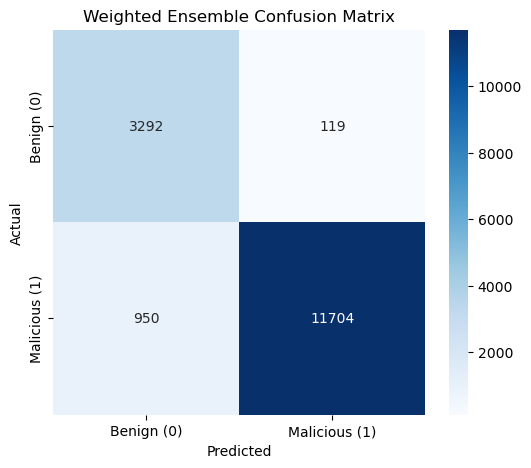

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted Ensemble Confusion Matrix")
plt.show()